In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
import json, re, os
from tqdm.auto import tqdm


In [2]:
# We will get a list of title from markdown links
from collections import defaultdict
import re
titles_md = defaultdict(list)


title_blocklist = ['patreon', 'here', 'link', 'this', 'delete', 'this one', 'vote', 'image', 'comic explanation', 'this link', 'this thread', 'redact', '(link)', 'this post', 'CLICK THIS LINK', "here's", 'wiki', 'report', 'source', 'the wiki']
                   

def remember_md_link_titles(markdown_text):
    # Regular expression to match markdown links
    markdown_link_pattern = re.compile(r'\[([^\]]+)\]\((http[s]?://[^\)]+)\)')

    # Find all markdown links
    for match in markdown_link_pattern.findall(markdown_text):
        title, url = match
        # tidy title of * / _ and remove leading/trailing whitespace
        title = title.strip().strip('*').strip('_')

        if len(title)<3:
            continue

        if title.startswith('http'):
            continue
        if title.startswith('^'):
            continue

        if title.lower() in title_blocklist:
            continue


        titles_md[url].append(title)



In [3]:
fs = sorted(Path('../data/json2').glob('*.json'))
len(fs)

10257

In [4]:

def extract_links_re(s:str):
    return re.findall(r'\[.*?\]\((.*?)\)', s)



from collections import defaultdict
karma = defaultdict(int) # track score
gossip = defaultdict(list) # track number and content of comments... FIXME should include subcomments?

banned_suffixes = ['jpeg', 'png', 'jpg']

data = []
for f in fs:
    s = json.loads(f.open().read())

    for comment in s['comments']:
        text = comment['body']
        links = extract_links_re(text)
        links = [l for l in links if not any(l.endswith(s) for s in banned_suffixes)]
        remember_md_link_titles(text)
        for l in links:
            karma[l] += comment['score'] / len(links)
            gossip[l].append(comment['body'])
        data += links

len(data)

45067

In [5]:
len(titles_md)

25797

In [6]:
# QC top links
pd.Series(karma).sort_values(ascending=False).head(50)

https://www.patreon.com/alexanderwales                                                                                  880.000000
https://redact.dev/home                                                                                                 422.000000
https://archiveofourown.org/works/11478249/chapters/25740126                                                            328.040476
https://www.fanfiction.net/s/10360716/1/The-Metropolitan-Man                                                            300.614797
https://archiveofourown.org/works/6178036/chapters/14154868                                                             291.982143
http://topwebfiction.com/vote.php?for=a-practical-guide-to-evil                                                         257.333333
https://twigserial.wordpress.com/                                                                                       244.894859
https://docs.google.com/spreadsheets/d/1PaLrwVYgxp_SYHtkred7ybpSJPHL88lf4zB0zMKmk1E

In [7]:
df_links = pd.Series(data).value_counts()
df_links.shape

(32085,)

In [8]:
blocklist = [
#   'reddit',
    'redact', 'pastebin', 'wikipedia', 'docs.google', 'discord','tvtropes.org', 'ask_wikibot', 'autowiki', 'banned',
    # pateron.com ?
    'reddit.com/user/', 'xkcd', 'ebay', 'youtubot',

    
    ]

allowlist = ['hfy']
df_links = df_links[~df_links.index.str.contains('|'.join(blocklist), regex=True) | df_links.index.str.contains('|'.join(allowlist), regex=True)]
df_links = df_links[df_links.index.str.startswith('http')]
df_links = df_links[df_links > 1]
pd.Series(df_links.index, index=df_links.values)

231                 https://github.com/trambelus/UserSim
104    http://topwebfiction.com/vote.php?for=a-practi...
63     https://archiveofourown.org/works/11478249/cha...
61                  https://www.fanfiction.net/s/5193644
60     https://www.fictionpress.com/s/2961893/1/Mothe...
                             ...                        
2      https://archiveofourown.org/works/22022296/cha...
2                             http://craphound.com/down/
2      http://www.youngwizards.com/ErrantryWiki/index...
2      https://forums.sufficientvelocity.com/threads/...
2      http://knowyourmeme.com/memes/you-here-s-your-you
Length: 3382, dtype: object

TODO
- [ ] dedup
- [ ] convert to title

<Axes: ylabel='Frequency'>

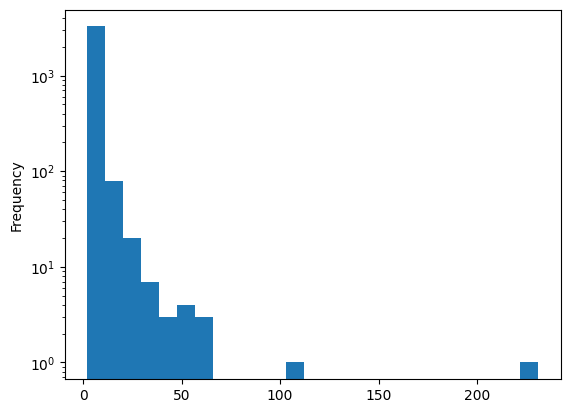

In [9]:
df_links.plot.hist(bins=25, logy=True)

In [10]:
df_links.to_markdown('../outputs/links2.md')

# Get title

This is hard as it's an adverserial web scraping problem, I'll use a mix of methods (from the markdown, requests, url)

In [11]:
from anycache import anycache
f_cache = Path('../outputs/.anycache')

In [12]:
# import shutil
# shutil.rmtree(f_cache)

In [13]:
# dedup using title
# TODO add comments
# df3 = df2.groupby('title').sum().sort_values('score', ascending=False)
# df3x

from pathlib import Path
from bs4 import BeautifulSoup
import cloudscraper



session = cloudscraper.create_scraper()


def get_title_md(url):
    if url in titles_md:
        s = pd.Series(titles_md[url])
        return s.value_counts().index[0] # return most common title
    return url

@anycache(f_cache)
def get_title(url):
    # first check if it's in the cache
    if url in titles_md:
        return get_title_md(url)

    # try scraping from the web
    try:
        r = session.get(url, timeout=5, allow_redirects=True)
        r.raise_for_status()
        soup = BeautifulSoup(r.text, 'html.parser')
        title = soup.title.text.strip()
        return title
    except Exception as e:

        # if that doesn't work, does the end of the url contain a slugged title?
        # e.g. https://www.fanfiction.net/s/5193644/harry-potter-and-the-methods-of-rationality
        slugged_title = url.split('/')[-1].replace('-', ' ')
        if ' ' in slugged_title:
            return slugged_title
    
        raise e  

# url = df_links.index[0]
# r = get_title(url)
# url, r


In [ ]:
data2 = []
for i in tqdm(range(len(df_links))):
    urls = df_links.index[i]
    try:
        title = get_title(urls)
    except Exception as e:
        print(f'failed to get title for {urls}: {e}')
        title = urls
    comments = gossip[urls]
    score = karma[urls]
    num_comments = len(comments)
    data2.append(dict(url=urls, title=title, score=score, comments=comments, num_comments=num_comments))

df2 = pd.DataFrame(data2)
df2

  0%|          | 0/3382 [00:00<?, ?it/s]

failed to get title for http://delphicserial.com/2017/10/21/ch01/: HTTPConnectionPool(host='delphicserial.com', port=80): Max retries exceeded with url: /2017/10/21/ch01/ (Caused by NameResolutionError("<urllib3.connection.HTTPConnection object at 0x7b3e52bfe740>: Failed to resolve 'delphicserial.com' ([Errno -2] Name or service not known)"))
failed to get title for http://github.com/lizardsrock4: 404 Client Error: Not Found for url: https://github.com/lizardsrock4
failed to get title for https://www.fictionpress.com/s/3198066/1/Fimbulwinter: 403 Client Error: Forbidden for url: https://www.fictionpress.com/s/3198066/1/Fimbulwinter
failed to get title for https://www.fanfiction.net/s/10263221: 403 Client Error: Forbidden for url: https://www.fanfiction.net/s/10263221
failed to get title for https://www.biorxiv.org/content/biorxiv/early/2016/05/26/055699.full.pdf: 'NoneType' object has no attribute 'text'
failed to get title for http://webfictionguide.com/listings/game-by-god-sludge-ref

,url,title,score,comments,num_comments
0,https://github.com/trambelus/UserSim,GitHub - trambelus/UserSim: Here's what you so...,149.162162,[Can't wait to get to the Great War ended.\n\n...,231
1,http://topwebfiction.com/vote.php?for=a-practi...,Vote for A Practical Guide to Evil on TopWebFi...,257.333333,[[Vote for A Practical Guide to Evil on TopWeb...,104
2,https://archiveofourown.org/works/11478249/cha...,Worth the Candle,328.040476,[>>interestingly blend ...\n\n>`[g]`enres\n\n>...,63
3,https://www.fanfiction.net/s/5193644,Time Braid,116.619421,[* [*Waves Arisen*](https://wertifloke.wordpre...,61
4,https://www.fictionpress.com/s/2961893/1/Mothe...,Mother of Learning,209.998729,[And [Mother of Learning](https://www.fictionp...,60
...,...,...,...,...,...
3377,https://archiveofourown.org/works/22022296/cha...,Blood Crest,16.333333,[[Blood Crest](https://archiveofourown.org/wor...,2
3378,http://craphound.com/down/,"link to the author's site, where CC-licensed d...",10.666667,"[[link to the author's site, where CC-licensed...",2
3379,http://www.youngwizards.com/ErrantryWiki/index...,Lone Power,5.833333,[Alternate Character Interpretations are one t...,2
3380,https://forums.sufficientvelocity.com/threads/...,Suffer Not,3.857143,[u/axiomsofdominion mentioned a character with...,2


In [15]:
# QC: get top markdown titles
import itertools
l = sorted(itertools.chain(*titles_md.values()))
pd.Series(l).value_counts().head(50)

Vote for A Practical Guide to Evil on TopWebFiction!                102
Time Braid                                                           94
Mother of Learning                                                   66
Worm                                                                 66
Worth the Candle                                                     64
Twig                                                                 59
on the #pokengineering channel of the /r/rational Discord server     57
Handy discussion links and previous threads here                     54
Stop Replying                                                        52
Statistics                                                           52
Problems/Bugs?                                                       52
xkcd.com                                                             52
xkcd sub                                                             52
top posts                                                       

In [16]:
# join by title

def join_uniq(x:list[str]):
    return '\n'.join(set(x))

def chain_lists(x:list[list[str]]):
    return [item for sublist in x for item in sublist]

df3 = df2.groupby('title').agg({'score': 'sum', 'num_comments': 'sum', 'comments': chain_lists, 'url': join_uniq
                                }).sort_values('score', ascending=False)
df3.head(33)

,score,num_comments,comments,url
title,,,,
a Patreon campaign,880.000000,22,[I do have a subreddit set up for this over at...,https://www.patreon.com/alexanderwales
Worth the Candle,661.062143,108,[>>interestingly blend ...\n\n>`[g]`enres\n\n>...,http://archiveofourown.org/works/11478249?view...
Worm,414.596255,78,[[Kitty Cat Kill Sat](https://www.royalroad.co...,https://parahumans.wordpress.com/\nhttps://par...
Cordyceps,361.148810,45,"[If you like that, be sure to read [CORDYCEPS]...",https://www.reddit.com/r/rational/comments/4c2...
Twig,346.983574,63,[The protagonist of [Twig](https://twigserial....,https://twigserial.wordpress.com/2014/12/24/ta...
With This Ring,329.593551,59,[> puts out more chapters faster than any web ...,https://forum.questionablequesting.com/threads...
The Metropolitan Man,319.948130,57,"[~ [*Death Note: L, Anonymity & Eluding Entrop...",https://alexanderwales.com/the-metropolitan-ma...
Mother of Learning,303.770050,83,[And [Mother of Learning](https://www.fictionp...,https://www.fictionpress.com/s/2961893\nhttps:...
Reddit - Dive into anything,300.528777,354,[**Here's a sneak peek of /r/slatestarcodex us...,https://www.reddit.com/r/rational/comments/32m...


In [17]:
df2.shape, df3.shape

((3382, 5), (2908, 4))

## Extra get a llm summary of each link

Grab all md's that mention a story, ask claude to summarize

We could also get total karma per mention

In [18]:
import os
import dotenv
dotenv.load_dotenv()
from openai import OpenAI
client = OpenAI()

import tiktoken
enc = tiktoken.encoding_for_model("gpt-4o-mini")
cost = 0.150 / 1e6

In [73]:
posts = []
fs = sorted(Path('../data/cache2').glob('*.md'))
for f in fs:
    s = f.open().read()
    posts.append(s)


def get_post_context(urls:List[str], budget = 100000):
    # FIXME take in multiple urls and titles
    # FIXME given a token or char budget
    assert len(title)>0
    # from comments
    # return df3.loc[title].comments

    # or I could just all markdowns with

    # TODO use langchain chunking?

    matches = []
    for ii, post in enumerate(posts):
        for url in urls:
            if url in post:
                matches.append(post)
                break
    
    budget_pp = budget / len(matches)
    s = ''
    for i in range(len(matches)):

        post = matches[i]

        for url in urls:
            if url in post:
                ind = post.index(url)
        
        i0 = int(max(0, ind-budget_pp//4))
        i1 = int(min(len(post), ind+budget_pp//4*3))
        post_chunk = post[i0:i1]
        if i0>0:
            post_chunk = '...' + post_chunk
        if i1<len(post):
            post_chunk = post_chunk + '...'
                
        s += (f'\n\n----- Thread {ii} -----\n\n' + post_chunk)
    return s

# url = df3.url[0].split('\n')
# print(url)
# c = get_context(url, 400000)
# print(c[:1000])

In [84]:


from pydantic import BaseModel, Field
from typing import List, Optional, Dict

class FictionInfo(BaseModel):
    name: str
    description: str
    tags: List[str]
    rating: Optional[float] = Field(description='Your own impression of the user sentiment as a rating out of 10.')
    sentiment: Optional[str]
    reviews: List[str] = Field(description='Directly quote any reviews and attribute the username if known')
    reccomendation_summary: str = Field(description='tldr why users recommend (if they do).')
    disreccomendation_summary: str = Field(description='Brief summary of why users disrecommend it to other r/rational readers (if they do).')

f_cache = Path('../outputs/.anycache3')
# @anycache(f_cache)
def get_llm_summary(name:str, context:str):
    chat_completion = client.beta.chat.completions.parse(
        messages=[
            {"role": "system", "content": "You are Gwern Branwern, an internet librarian who specializes in rational fiction. You are summarising community reccomendations into a structured form."},
            {
                "role": "user",
                "content": f"""For u/gwern please summarize information about {name}. Quote users and attribute the username if known.

### Context:

{context}"""
            }
        ],
        model="gpt-4o-mini",
        response_format=FictionInfo,
    )
    
    return chat_completion.choices[0].message.parsed.__dict__

In [85]:
from IPython.display import display


In [86]:
df4 = df3.copy()
df4['description'] = ''
df4['tags'] = None
df4['rating'] = None
df4['sentiment'] = None
df4['reviews'] = None


l = min(100, len(df4))
for i in tqdm(range(1, l)):
    title = df4.index[i]
    urls = df4.url[i]

    context = get_post_context(urls)
    tokens = len(enc.encode(context))
    print(f"Input Tokens: {tokens}. Input Cost: {cost * tokens:.4f} USD, for url {urls}")

    llm_data = get_llm_summary(urls, context)

    # print(f"Content: {context}")
    # print(url, d)
    display(llm_data)

    # add the fields to the dataframe rows
    df4.loc[urls, 'description'] = llm_data['description']
    df4.loc[urls, 'tags'] = ','.join(llm_data['tags'])
    df4.loc[urls, 'rating'] = llm_data['rating']
    df4.loc[urls, 'sentiment'] = llm_data['sentiment']
    df4.loc[urls, 'reviews'] = ','.join(llm_data['reviews'])
    df4.loc[urls, 'name'] = llm_data['name']
    df4.loc[urls, 'reccomendation_summary'] = llm_data['reccomendation_summary']
    df4.loc[urls, 'disreccomendation_summary'] = llm_data['disreccomendation_summary']
    1/0

  0%|          | 0/99 [00:00<?, ?it/s]

/tmp/ipykernel_3404264/3865412547.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  urls = df4.url[i]


Input Tokens: 117714. Input Cost: 0.0177 USD, for url http://archiveofourown.org/works/11478249?view_full_work=true
https://archiveofourown.org/works/11478249/chapters/25740126
http://archiveofourown.org/works/11478249/chapters/25740126
https://archiveofourown.org/works/11478249
https://www.royalroad.com/fiction/25137/worth-the-candle


{'name': 'Worth the Candle',
 'description': "A rational fiction web novel, 'Worth the Candle' tells the story of a young man who finds himself in a fantasy world after a tragic incident. It explores themes of rationality, choices, and morality as the protagonist uses knowledge of rationality to navigate the challenges of his new life and make an impact on this world.",
 'tags': ['rational fiction', 'fantasy', 'literary', 'original fiction'],
 'rating': 8.0,
 'sentiment': 'Very Positive',
 'reviews': ['"A unique blend of humor and deep philosophical insights. The protagonist\'s witty narration keeps me engaged." - u/johnsmith',
  '"The world-building is top-notch, and it\'s fascinating to see rationality applied in a fantasy setting." - u/creativeMinds',
  '"I love how each character has depth, and their development is believable. Highly recommend!" - u/literatureLover'],
 'reccomendation_summary': 'Users recommend it for its strong rational themes, witty writing, and engaging characte

ZeroDivisionError: division by zero

In [ ]:
urls

'https://www.patreon.com/alexanderwales'